In [1]:
import sys
sys.path.append('../../../../')

In [2]:
from CADETProcess.processModel import ComponentSystem
component_system = ComponentSystem(2)

from CADETProcess.processModel import Inlet, Outlet
feed = Inlet(component_system, 'feed')
eluent = Outlet(component_system, 'eluent')
outlet = Outlet(component_system, 'outlet')

from CADETProcess.processModel import FlowSheet
flow_sheet = FlowSheet(component_system)
flow_sheet.add_unit(feed)
flow_sheet.add_unit(eluent)
flow_sheet.add_unit(outlet)

In [3]:
from CADETProcess.processModel import Process
process = Process(flow_sheet, 'batch_elution')

In [4]:
process.cycle_time = 10     # s

In [5]:
process.add_event('inject_on', 'flow_sheet.feed.flow_rate', 1, 0)
process.add_event('inject_off', 'flow_sheet.feed.flow_rate', 0, 1)

Event(name=inject_off, parameter_path=flow_sheet.feed.flow_rate, state=0, time=1.0, indices=[(slice(None, None, None),)])

In [6]:
process.add_event('conc_high', 'flow_sheet.feed.c', 1, 0, indices=0)
process.add_event('conc_low', 'flow_sheet.feed.c', 0, 1, indices=0)

Event(name=conc_low, parameter_path=flow_sheet.feed.c, state=0, time=1.0, indices=[(np.int64(0),)])

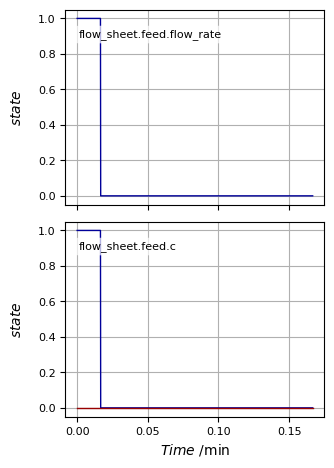

In [7]:
_ = process.plot_events()

In [8]:
from examples.batch_elution.process import flow_sheet

from CADETProcess.processModel import Process
process = Process(flow_sheet, 'batch elution')
process.cycle_time = 600
Q = 60e-6/60

In [9]:
process.add_event('feed_on', 'flow_sheet.feed.flow_rate', Q)
process.add_event('feed_off', 'flow_sheet.feed.flow_rate', 0.0)

process.add_event('eluent_off', 'flow_sheet.eluent.flow_rate', 0.0)
process.add_event_dependency('eluent_off', ['feed_on'])

In [10]:
from examples.batch_elution.process import flow_sheet

from CADETProcess.processModel import Process
process = Process(flow_sheet, 'batch elution')
Q = 60e-6/60
process.add_event('feed_on', 'flow_sheet.feed.flow_rate', Q)
process.add_event('feed_off', 'flow_sheet.feed.flow_rate', 0.0)

Event(name=feed_off, parameter_path=flow_sheet.feed.flow_rate, state=0.0, time=0.0, indices=[(slice(None, None, None),)])

In [11]:
process.add_event('eluent_on', 'flow_sheet.eluent.flow_rate', Q, dependencies=['feed_off'])

Event(name=eluent_on, parameter_path=flow_sheet.eluent.flow_rate, state=1e-06, time=0.0, indices=[(slice(None, None, None),)])

In [12]:
process.feed_off.time = 10
print(f'feed_off: {process.feed_off.time}')
print(f'eluent_on: {process.eluent_on.time}')

feed_off: 10.0
eluent_on: 10.0


In [13]:
import copy
import numpy as np

from CADETProcess.processModel import ComponentSystem
component_system = ComponentSystem(2)

from CADETProcess.processModel import Inlet
inlet = Inlet(component_system, 'inlet')

from CADETProcess.processModel import Inlet, LumpedRateModelWithPores, Outlet
inlet = Inlet(component_system, name='inlet')
column = LumpedRateModelWithPores(component_system, 'column')
outlet = Outlet(component_system, 'outlet')

from CADETProcess.processModel import FlowSheet, Process

flow_sheet = FlowSheet(component_system)
flow_sheet.add_unit(inlet)
flow_sheet.add_unit(column)
flow_sheet.add_unit(outlet)

flow_sheet.add_connection(inlet, column)
flow_sheet.add_connection(column, outlet)

def setup_process():
    process = Process(flow_sheet, 'Demo Indices')
    process.cycle_time = 10

    return process

In [14]:
process = setup_process()

process.add_event(
    'film_diffusion_all', 'flow_sheet.column.film_diffusion', [1e-6, 1e-6], time=0
)
print(column.film_diffusion)

[1e-06, 1e-06]


In [15]:
process.add_event(
    'film_diffusion_index_0', 'flow_sheet.column.film_diffusion', 1e-7, indices=0, time=1
)
print(column.film_diffusion)

[1e-07, 1e-06]


In [16]:
process.add_event(
    'film_diffusion_index_10', 'flow_sheet.column.film_diffusion', [2e-7, 3e-7], indices=[1, 0], time=2
)
print(column.film_diffusion)

[3e-07, 2e-07]


In [17]:
process = setup_process()

process.add_event(
    'flow_rate_all', 'flow_sheet.inlet.flow_rate', [0, 1, 2, 3], time=0
)
print(inlet.flow_rate)

[0. 1. 2. 3.]


In [18]:
process.add_event(
    'flow_rate_index_0', 'flow_sheet.inlet.flow_rate', 1, indices=0, time=1
)
print(inlet.flow_rate)

[1. 1. 2. 3.]


In [19]:
process.add_event(
    'flow_rate_fill_all', 'flow_sheet.inlet.flow_rate', 1, time=2
)
print(inlet.flow_rate)

[1. 0. 0. 0.]


In [20]:
process.add_event(
    'flow_rate_fill_subset', 'flow_sheet.inlet.flow_rate', [2, 1], time=3
)
print(inlet.flow_rate)

[2. 1. 0. 0.]


In [21]:
process = setup_process()

evt = process.add_event(
    'c_all', 'flow_sheet.inlet.c',
    [[0, 1, 2, 3], [4, 5, 6, 7]],
    time=0
)
print(inlet.c)

[[0. 1. 2. 3.]
 [4. 5. 6. 7.]]


In [22]:
evt = process.add_event(
    'c_single', 'flow_sheet.inlet.c', 1, indices=(0, 0), time=1
)
print(inlet.c)

[[1. 1. 2. 3.]
 [4. 5. 6. 7.]]


In [23]:
evt = process.add_event(
    'c_multi', 'flow_sheet.inlet.c', [2, 3], indices=[(0, 0), (1, 1)], time=2
)
print(inlet.c)

[[2. 1. 2. 3.]
 [4. 3. 6. 7.]]


In [24]:
evt = process.add_event(
    'c_row', 'flow_sheet.inlet.c', 1, indices=np.s_[0, :], time=3
)
print(inlet.c)

[[1. 1. 1. 1.]
 [4. 3. 6. 7.]]


In [25]:
evt = process.add_event(
    'c_poly', 'flow_sheet.inlet.c', [2, [1, 2]], time=4
)
print(inlet.c)

[[2. 0. 0. 0.]
 [1. 2. 0. 0.]]


In [26]:
from examples.load_wash_elute.lwe_concentration import flow_sheet

from CADETProcess.processModel import Process
process = Process(flow_sheet, 'lwe')
process.cycle_time = 15000.0

import numpy as np
import matplotlib.pyplot as plt

time = np.linspace(0, process.cycle_time, 1001)
c = np.sin(time/1000) + 1
_ = plt.plot(time/60, c)
plt.ylabel('c / mM')
plt.xlabel('time / min')

Text(0.5, 0, 'time / min')

In [27]:
process.add_concentration_profile('inlet', time, c, components=-1)

In [28]:
_ = process.plot_events()

In [29]:
from examples.load_wash_elute.lwe_concentration import flow_sheet

from CADETProcess.processModel import Process
process = Process(flow_sheet, 'lwe')
process.cycle_time = 15000.0

In [30]:
process.add_flow_rate_profile('inlet', time, c)
_ = process.plot_events()

In [31]:
from examples.batch_elution.process import process

In [32]:
process.add_parameter_sensitivity('column.total_porosity')

In [33]:
process.add_parameter_sensitivity(
    'feed.c',
    components=['A'],
    polynomial_coefficients=0,
    section_indices=0,
)